In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from joblib import dump, load
import skimage.transform as tx
import skimage.io as io

In [8]:
df = pd.read_csv("crazy_dataset.csv")
df.head()

,x1,x2,y
0,17.328264,15.386803,1
1,19.162757,-276.665450,1
2,18.243497,-32.337063,1
3,16.263083,-8.270111,1
4,16.683013,272.555702,0


In [15]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1]

scaler = StandardScaler()
X = scaler.fit_transform(X)

svm_clf= SVC(C=10,kernel='rbf', gamma=0.8)
svm_clf.fit(X,y)

SVC(C=10, gamma=0.8)

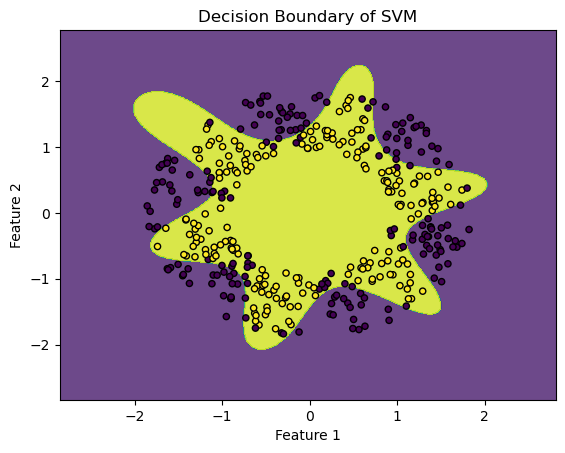

In [16]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict the function value for the whole grid
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour and training examples
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of SVM')
plt.show()

In [12]:
def plot_svc_boundary(model, ax=None, plot_margin=True, plot_support=True):
    """Plot the decision boundary for a 2D SVC"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 50)
    y = np.linspace(ylim[0], ylim[1], 50)
    Y, X = np.meshgrid(y, x)

    # shape data
    xy = np.vstack([X.ravel(), Y.ravel()]).T

    # get the decision boundary
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    if plot_margin:
        levels=[-1, 0, 1]
        linestyles=['--', '-', '--']
    else:
        levels=[0]
        linestyles=['-']
    ax.contour(X, Y, P, colors='k', levels=levels, alpha=0.5, linestyles=linestyles)


    # plot support vectorscnf_mtx
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    return ax  # in case plot was created here

[1]


/tmp/ipykernel_29831/78294109.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obs = [(20 -X_mean[0])/X_std[0], (0 - X_mean[1])/X_std[1]]


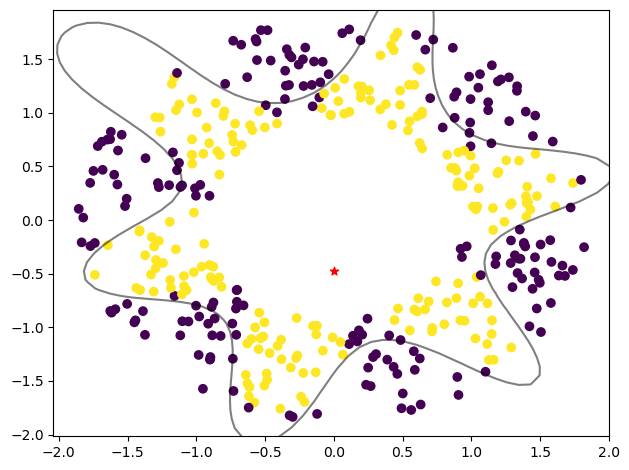

In [18]:
df = pd.read_csv("crazy_dataset.csv")
    #print(df.head())
    
X = df.iloc[:, :-1]
y= df.y

X_mean = X.mean()
X_std = X.std()

X = (X - X.mean()) / X.std()

ng, ax = plt.subplots(tight_layout=True)
ax.scatter(X.x1, X.x2, c=y)

clf= SVC(kernel="rbf", C=10, gamma=0.8)
clf.fit(X.values,y)

obs = [(20 -X_mean[0])/X_std[0], (0 - X_mean[1])/X_std[1]]

y_hat= clf.predict([obs])
plot_svc_boundary(clf, ax, plot_margin=False, plot_support=False)
print(y_hat)
plt.scatter(obs[0], obs[1], c = "red", marker = "*")

In [20]:
df = pd.read_csv("mnist.zip")
df = df[:1000]
X = df.iloc[:, :-1]
y = df.y
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
clf = SVC()
print("A treinar modelo....")
clf.fit(X_train, y_train)

A treinar modelo....


SVC()

In [21]:
print("A classificar....")
y_pred = clf.predict(X_test)

A classificar....


In [22]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))
dump(clf, "clf.pkl")

[[23  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  1  0  0  0  0  0  0]
 [ 1  0 17  0  0  0  0  0  0  0]
 [ 0  0  1 13  0  0  0  0  0  0]
 [ 0  0  1  0 21  0  0  0  0  1]
 [ 1  0  0  1  0 18  0  0  1  0]
 [ 0  0  1  0  0  0 16  0  0  0]
 [ 0  0  1  0  0  0  0 31  0  0]
 [ 0  0  0  0  1  2  0  0 16  0]
 [ 1  0  0  0  0  0  0  0  0 10]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      0.95      0.98        22
           2       0.81      0.94      0.87        18
           3       0.87      0.93      0.90        14
           4       0.95      0.91      0.93        23
           5       0.90      0.86      0.88        21
           6       1.00      0.94      0.97        17
           7       1.00      0.97      0.98        32
           8       0.94      0.84      0.89        19
           9       0.91      0.91      0.91        11

    accuracy                           0.93       200
   macro avg       

['clf.pkl']

In [33]:
import skimage.transform as tx
import skimage.io as io
from sklearn.datasets import fetch_openml
import skimage.color as color

In [34]:
clf = load('clf.pkl')
image = io.imread("./sample_imgs/three.jpg", as_gray=True)
image = image/ 255

image_resize = tx.resize(image,(28,28), anti_aliasing =True)

x_im_array = image_resize.flatten()

prediction = clf.predict([x_im_array])

print(prediction[0])

3


/home/mike/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [39]:
image = df.iloc[999].values

image  = image.reshape(28,28)

io.imshow(image, cmap='gray')
plt.title(f'MNIST Image - Label: {label}')
plt.axis('off')
plt.show()

ValueError: cannot reshape array of size 785 into shape (28,28)

In [40]:
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


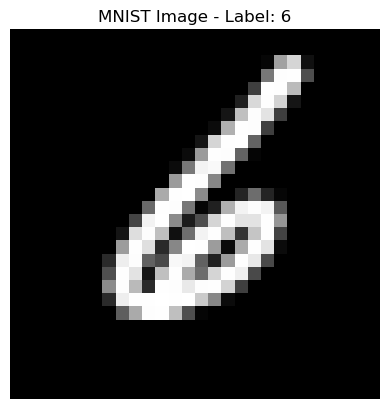

In [41]:
mnist = fetch_openml('mnist_784', version=1)

# Extract the 1000th image and its label
image = mnist.data.iloc[999].values  # MNIST data in fetch_openml is 0-indexed
label = mnist.target.iloc[999]

# Reshape the image to 28x28 pixels
image = image.reshape(28, 28)

# Display the image using matplotlib
plt.imshow(image, cmap='gray')
plt.title(f'MNIST Image - Label: {label}')
plt.axis('off')  # Hide axis
plt.show()

In [44]:
import skimage.io
skimage.io.imsave("test.png",image)

/tmp/ipykernel_29831/3351158887.py:2: UserWarning: test.png is a low contrast image
  skimage.io.imsave("test.png",image)


TypeError: Cannot handle this data type: (1, 1), <i8